In [1]:
## pip install wordcloud

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import string

from wordcloud import WordCloud
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TreebankWordTokenizer
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB,MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay,
    classification_report
    )

import warnings
warnings.filterwarnings('ignore')



## Loading Data

In [3]:
df=pd.read_csv('text_dataset.csv')

In [4]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


## EDA

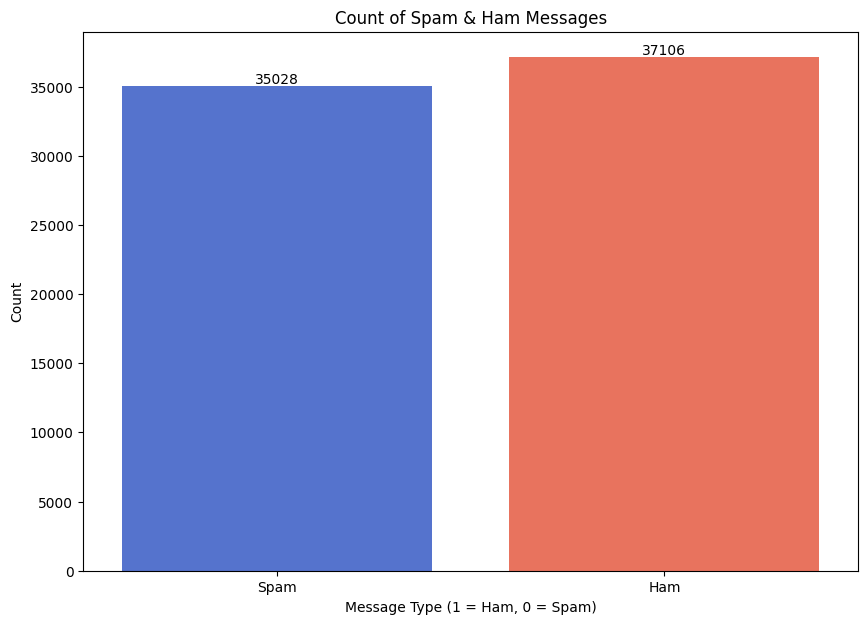

In [5]:
plt.figure(figsize=(10,7))
ax = sns.countplot(x=df['label'],palette=['royalblue','tomato'])

plt.xlabel("Message Type (1 = Ham, 0 = Spam)")
plt.ylabel("Count")
plt.title("Count of Spam & Ham Messages")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x()+p.get_width()/2,p.get_height()),
                ha="center",va="bottom",color='black',fontsize=10
                )

plt.xticks([0,1],["Spam","Ham"])
plt.show()

In [6]:
df

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
...,...,...,...,...
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0


In [7]:
label_status = df['label'].value_counts()
transactions=label_status.index
quantity = label_status.values

pie_df=pd.DataFrame({
    "Spam or Ham": transactions,
    "count":quantity
})

figures=px.pie(
              pie_df,
              names=transactions,
              values=quantity,
              hole=.60,
              title="Spam & Ham Status"
)
figures.show()

In [8]:
label_status

label
1    37106
0    35028
Name: count, dtype: int64

In [9]:
df.shape

(72134, 4)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [11]:
df2=df.drop('Unnamed: 0',axis=1)

In [12]:
df2.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [13]:
df2.isnull().sum()

title    558
text      39
label      0
dtype: int64

In [14]:
df2.fillna(' ',inplace=True)

In [15]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   72134 non-null  object
 1   text    72134 non-null  object
 2   label   72134 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [16]:
features=[['title','text']]
labels=['label']

In [17]:
df2.shape

(72134, 3)

## Preprocessing

wordcloud

In [18]:
def plot_wordCloud(text,title):
    wordcloud = WordCloud( height=800,width=600 ,background_color='white').generate(text)
    plt.figure(figsize=(10,14))
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()


fake_text=' '.join(df2[df2['label']==0]['text'])
real_text=' '.join(df2[df2['label']==1]['text'])

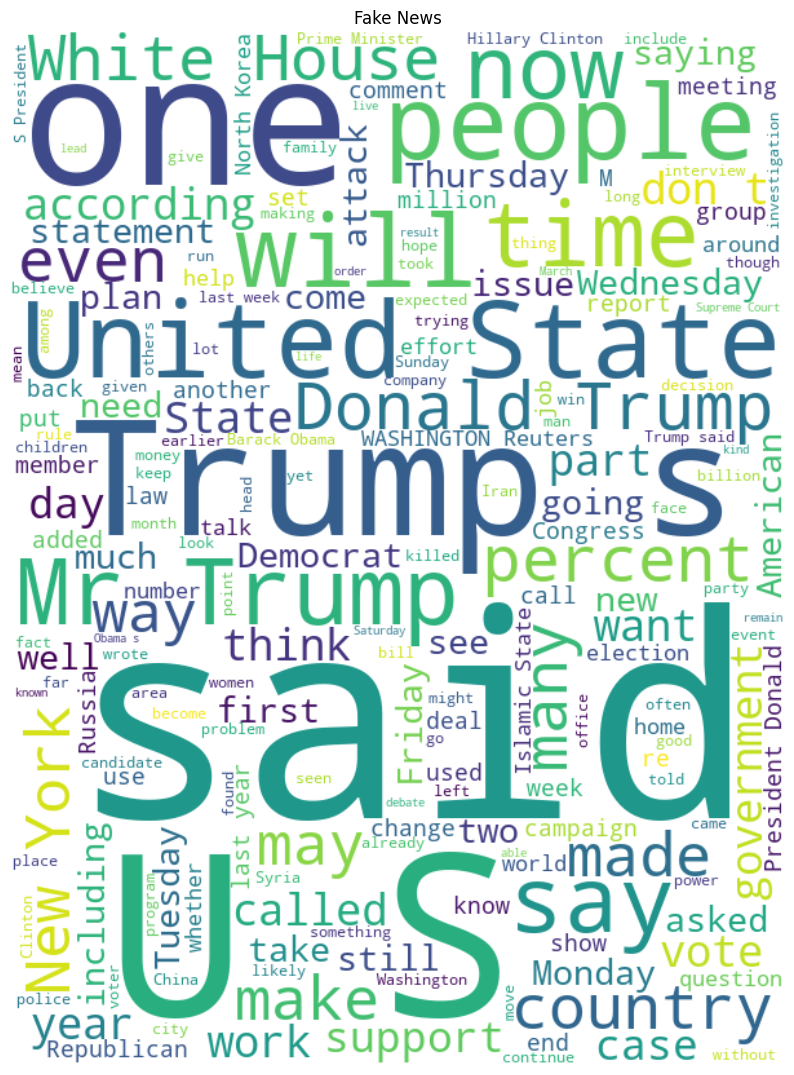

In [19]:
plot_wordCloud(fake_text,'Fake News')

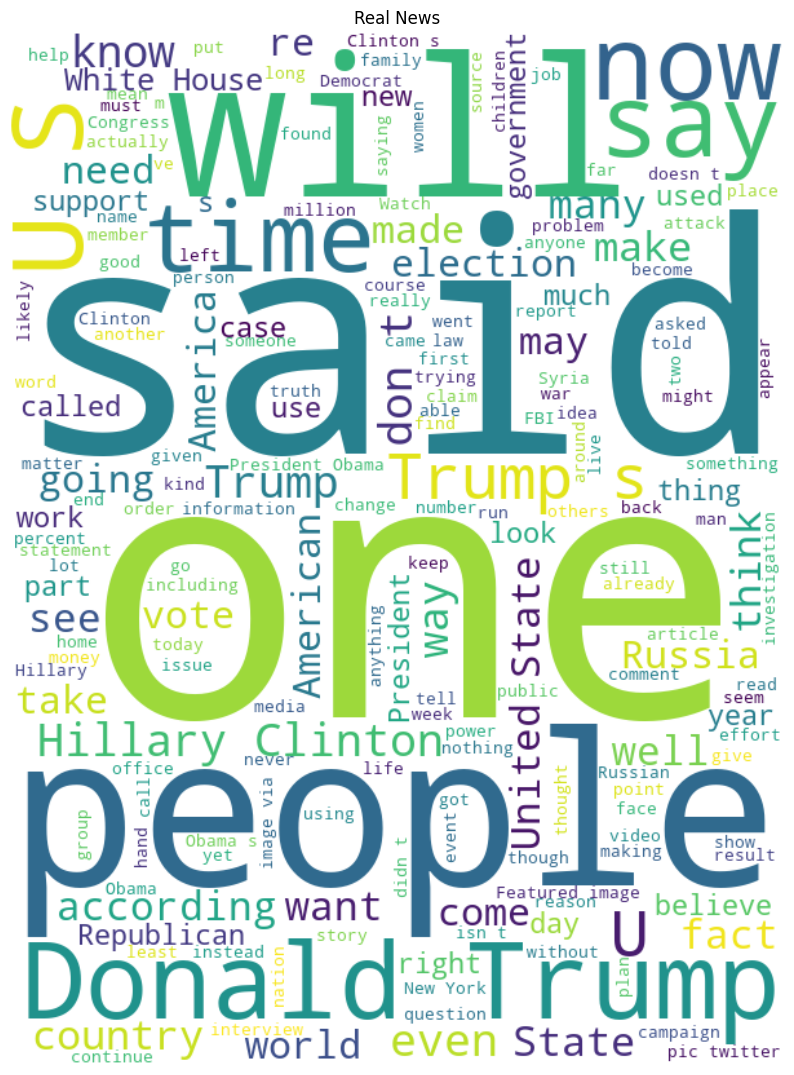

In [20]:
plot_wordCloud(real_text,'Real News')

Remove punctuation and stopwords

In [21]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [22]:
stopwords.fileids()

['albanian',
 'arabic',
 'azerbaijani',
 'basque',
 'belarusian',
 'bengali',
 'catalan',
 'chinese',
 'danish',
 'dutch',
 'english',
 'finnish',
 'french',
 'german',
 'greek',
 'hebrew',
 'hinglish',
 'hungarian',
 'indonesian',
 'italian',
 'kazakh',
 'nepali',
 'norwegian',
 'portuguese',
 'romanian',
 'russian',
 'slovene',
 'spanish',
 'swedish',
 'tajik',
 'tamil',
 'turkish']

In [23]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [24]:
stopword=stopwords.words('english')

def remove_punc_stopwords(text):
    ## remove punctuation
    remove_punc=''.join([word for word in text if word not in string.punctuation])
    
    ## remove stopwords
    split_text=remove_punc.split()
    text=' '.join([word for word in split_text if word.lower() not in stopword ])

    return  text

In [25]:
text_column='text'
label_column='label'
df2[text_column] = df2[text_column].apply(remove_punc_stopwords)

In [26]:
df2[text_column]

0        comment expected Barack Obama Members FYF911 F...
1                               post votes Hillary already
2        demonstrators gathered last night exercising c...
3        dozen politically active pastors came private ...
4        RS28 Sarmat missile dubbed Satan 2 replace SS1...
                               ...                        
72129    WASHINGTON Reuters Hackers believed working Ru...
72130    know fantasyland Republicans never questioned ...
72131    Migrants Refuse Leave Train Refugee Camp Hunga...
72132    MEXICO CITY Reuters Donald Trump’s combative s...
72133    Goldman Sachs Endorses Hillary Clinton Preside...
Name: text, Length: 72134, dtype: object

Lemmatization

In [27]:
lm=WordNetLemmatizer()

In [28]:
def lematize(text):
    lema=' '.join([lm.lemmatize(word) for word in text.split()])
    return lema

In [29]:
df2[text_column]=df2[text_column].apply(lematize)

In [30]:
df2[text_column]

0        comment expected Barack Obama Members FYF911 F...
1                                post vote Hillary already
2        demonstrator gathered last night exercising co...
3        dozen politically active pastor came private d...
4        RS28 Sarmat missile dubbed Satan 2 replace SS1...
                               ...                        
72129    WASHINGTON Reuters Hackers believed working Ru...
72130    know fantasyland Republicans never questioned ...
72131    Migrants Refuse Leave Train Refugee Camp Hunga...
72132    MEXICO CITY Reuters Donald Trump’s combative s...
72133    Goldman Sachs Endorses Hillary Clinton Preside...
Name: text, Length: 72134, dtype: object

Train_Test_Split

In [31]:
X=df2['text']
y=df2['label']

In [32]:
xtrain_raw,xtest_raw,ytrain,ytest=train_test_split(X,y,test_size=0.3,random_state=10)

In [33]:
xtrain_raw.shape

(50493,)

In [34]:
ytrain.shape

(50493,)

In [35]:
xtest_raw.shape

(21641,)

In [36]:
ytest.shape

(21641,)

Vectorization

In [37]:
tf_Vec=TfidfVectorizer()

In [38]:
xtrain=tf_Vec.fit_transform(xtrain_raw)
xtest=tf_Vec.transform(xtest_raw)

In [39]:
xtrain.shape  ## First number: 50493--> Number of training documents (rows)
              ## Second number: 301025 --> Number of unique words (features) in training data

(50493, 301025)

In [40]:
xtest.shape

(21641, 301025)

Evaluation Functons

In [41]:
def evaluate_model(model,xtest,ytest):
    y_pred=model.predict(xtest)
    accuracy=accuracy_score(ytest,y_pred)
    cm=confusion_matrix(ytest,y_pred)
    
    return {
        'Accuracy':accuracy,
        'Confusion Matrix':cm,
       
    }

In [42]:
def plot_confusion_matrix(cm,title):
    plt.figure(figsize=(10,7))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=['Predicted 0','Predicted 1'],
                yticklabels=['Actual 0','Actual 1']
                )
    
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

## Model Training

Multinomial Naive Bayes

{'Accuracy': 0.8756989048565224, 'Confusion Matrix': array([[9535,  902],
       [1788, 9416]])}


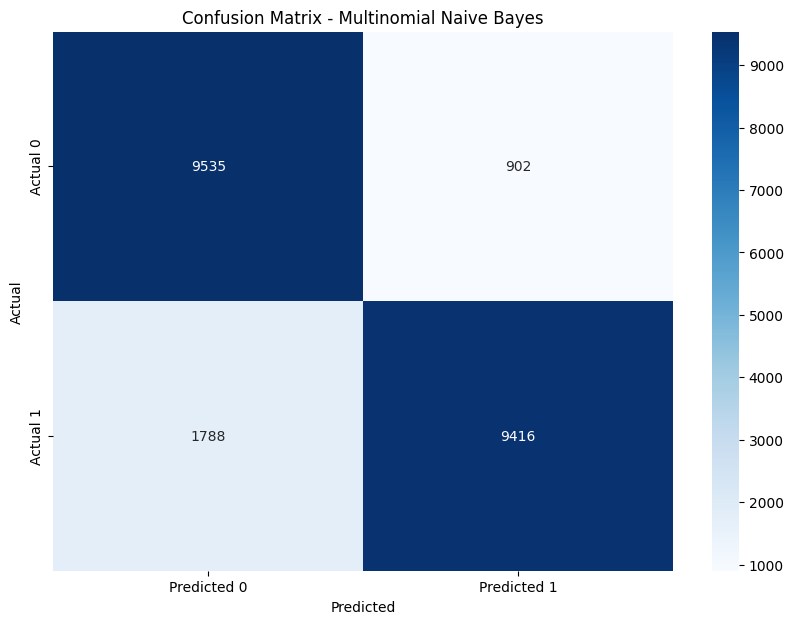

In [43]:
model=MultinomialNB()
mn_model=model.fit(xtrain,ytrain)

mnb=evaluate_model(mn_model,xtest,ytest)
print(mnb)

cm_mn=mnb['Confusion Matrix']
plot_cm=plot_confusion_matrix(cm_mn,'Confusion Matrix - Multinomial Naive Bayes')

Classification Report

In [44]:
print("Classification_Report: ")
print(classification_report(ytest,model.predict(xtest),digits=3))

Classification_Report: 
              precision    recall  f1-score   support

           0      0.842     0.914     0.876     10437
           1      0.913     0.840     0.875     11204

    accuracy                          0.876     21641
   macro avg      0.877     0.877     0.876     21641
weighted avg      0.879     0.876     0.876     21641



AUC & ROC Curve

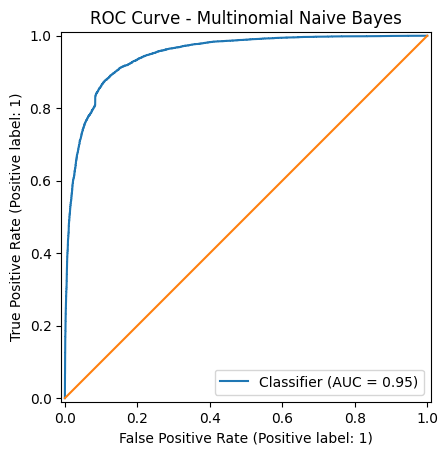

In [45]:
mnb_prob = model.predict_proba(xtest)[:,1]
RocCurveDisplay.from_predictions(ytest,mnb_prob)

plt.plot([0,1],[0,1])
plt.title("ROC Curve - Multinomial Naive Bayes")
plt.show()

Bernouli Naive Bayes

{'Accuracy': 0.8535187837900282, 'Confusion Matrix': array([[ 8386,  2051],
       [ 1119, 10085]])}


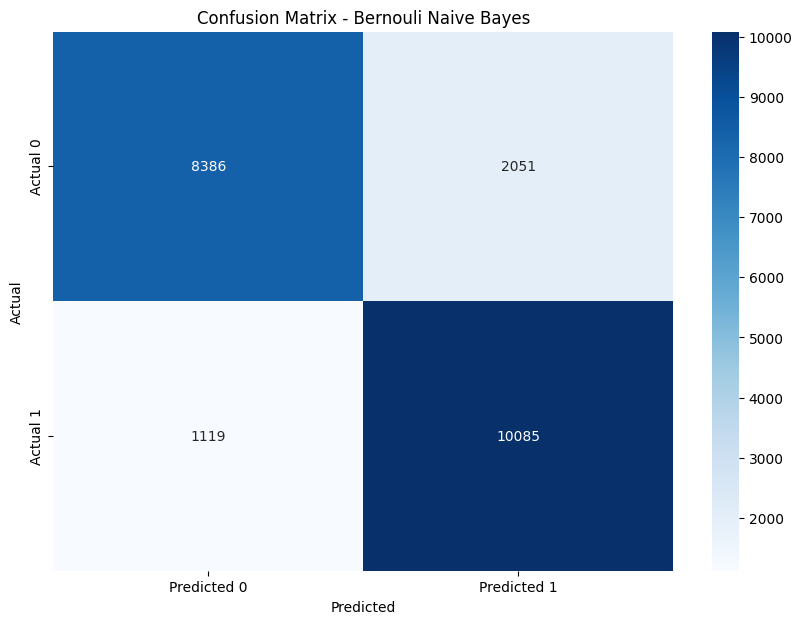

In [46]:
bnb_model=BernoulliNB()
bnb_model.fit(xtrain,ytrain)

bnb_results = evaluate_model(bnb_model,xtest,ytest)
print(bnb_results)

plot_confusion_matrix(bnb_results['Confusion Matrix'], 'Confusion Matrix - Bernouli Naive Bayes')


Classification report

In [47]:
print("Classification Report: ")
print(classification_report(ytest,bnb_model.predict(xtest)))

Classification Report: 
              precision    recall  f1-score   support

           0       0.88      0.80      0.84     10437
           1       0.83      0.90      0.86     11204

    accuracy                           0.85     21641
   macro avg       0.86      0.85      0.85     21641
weighted avg       0.86      0.85      0.85     21641



ROC Curve


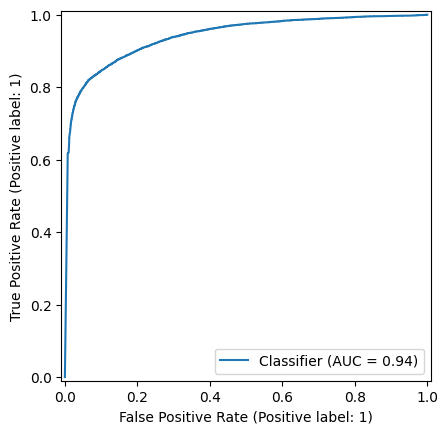

In [48]:
bnb_proba = bnb_model.predict_proba(xtest)[:,1] 
RocCurveDisplay.from_predictions(ytest,bnb_proba)

Logistic Regression

{'Accuracy': 0.9515271937525992, 'Confusion Matrix': array([[ 9822,   615],
       [  434, 10770]])}


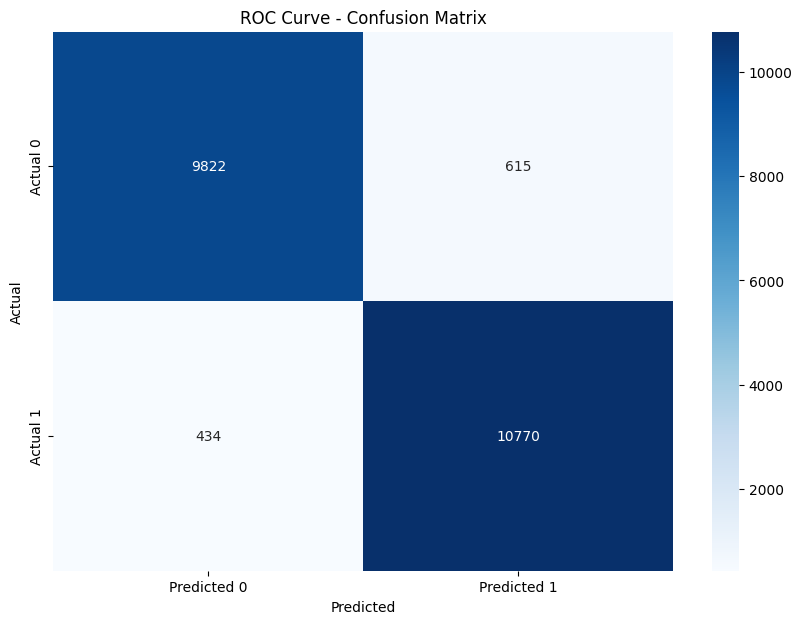

In [49]:
lr_model=LogisticRegression()
lr_model.fit(xtrain,ytrain)

lr_results=evaluate_model(lr_model,xtest,ytest)
print(lr_results)

plot_confusion_matrix(lr_results['Confusion Matrix'],'ROC Curve - Confusion Matrix')

Classification Report

In [50]:
print("Classification Report: ")
print(classification_report(ytest,lr_model.predict(xtest)))


Classification Report: 
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     10437
           1       0.95      0.96      0.95     11204

    accuracy                           0.95     21641
   macro avg       0.95      0.95      0.95     21641
weighted avg       0.95      0.95      0.95     21641



ROC Curve

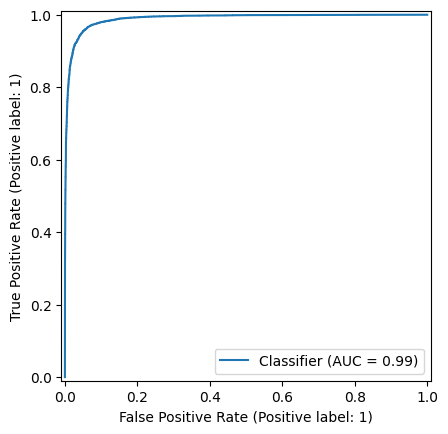

In [51]:
lr_proba= lr_model.predict_proba(xtest)[:,1]
RocCurveDisplay.from_predictions(ytest,lr_proba)

## Evaluation All Together

In [82]:
def plot_histogram(model_names,model_values,title):
    fig,ax = plt.subplots(figsize=(10,7))
    bars=ax.bar(model_names,model_values)

    plt.xlabel("Model Names")
    plt.ylabel("Accuracy")
    plt.title(f"{title} for diffterent models")

    for bar in bars:
        yval=bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2,yval,round(yval,3),
                color="black",
                ha='center',
                va='bottom'
                )

    plt.show()

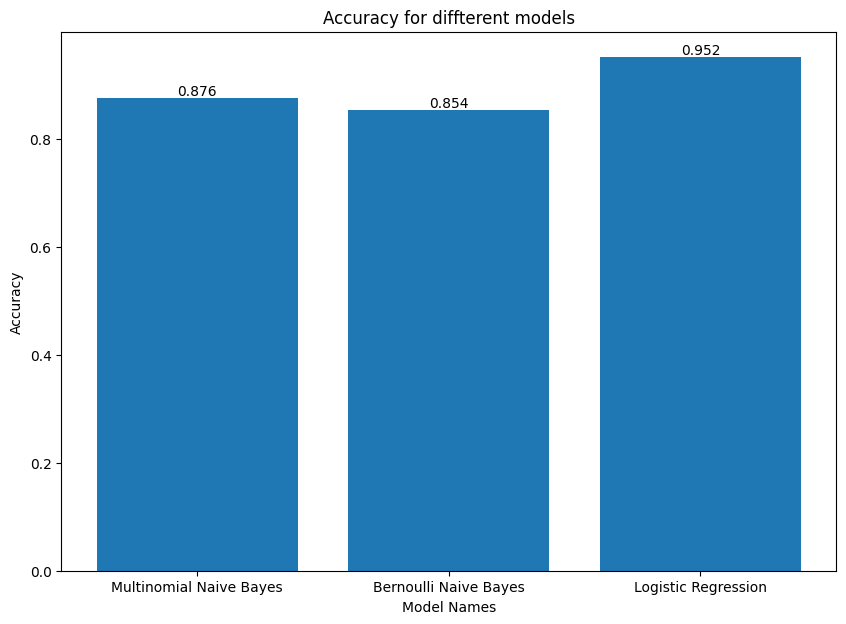

In [83]:
model_names= ['Multinomial Naive Bayes', 'Bernoulli Naive Bayes', 'Logistic Regression']
model_values=[mnb['Accuracy'],bnb_results['Accuracy'],lr_results['Accuracy']]
plot_histogram(model_names,model_values,'Accuracy')

## Inference : Input Random Text and Make a Prediction

In [ ]:
models=[model,bnb_model,lr_model]
def predict_for_text(text):
    preprocessText=remove_punc_stopwords(text)
    lematized_text=lematize(preprocessText)
    vectorized_text=tf_Vec.transform([lematized_text])

    for model in models:
        precdicted=model.predict(vectorized_text)
        
        print(f"Model Name: {type(model).__name__}")
        print(f"Prediction : {precdicted[0]}")
        


In [84]:
df2['text'][72129]

'WASHINGTON Reuters Hackers believed working Russian government broke Democratic National Committee’s computer network spied internal communication accessed research presumptive Republican presidential nominee Donald Trump committee security expert said Tuesday Two separate group entered DNC’s system one read email chat communication nearly year detected according committee CrowdStrike cyber firm helped clean breach Russian spy also targeted network Trump Democratic presidential candidate Hillary Clinton well computer Republican political action committee Washington Post quoted US official saying although detail available Clinton campaign official said evidence campaign’s information system hacked Russian government spokesman denied involvement breach “I completely rule possibility Russian government government body involved this” Dmitry Peskov Kremlin spokesman told Reuters Moscow intrusion emblematic sophistication Russian hacker intelligence official long viewed talented US adversar

In [85]:
text='WASHINGTON Reuters Hackers believed working Russian government broke Democratic National Committee’s computer network spied internal communication accessed research presumptive Republican presidential nominee Donald Trump committee security expert said Tuesday Two separate group entered DNC’s system one read email chat communication nearly year detected according committee CrowdStrike cyber firm helped clean breach Russian spy also targeted network Trump Democratic presidential candidate Hillary Clinton well computer Republican political action committee Washington Post quoted US official saying although detail available Clinton campaign official said evidence campaign’s information system hacked Russian government spokesman denied involvement breach “I completely rule possibility Russian government government body involved this” Dmitry Peskov Kremlin spokesman told Reuters Moscow intrusion emblematic sophistication Russian hacker intelligence official long viewed talented US adversary cyberspace Democratic Party aware effort hack Trump material two month US intelligence agency involved effort find behind hacking source familiar Trump opposition research said source said Democratic Party operative believed hacking conducted Russian government research includes material Trump’s business effort Azerbaijan Georgia Serbia Russia according information made available Reuters Cyber attack political candidate organization common worldwide US National Intelligence Director James Clapper said last month aware attempted hack campaign related group expected see Nov 8 presidential election nears US Representative Jim Langevin Democrat cofounder congressional cybersecurity caucus said “disconcerting” independent group penetrated DNC one able “to stay embedded nearly year” group extremely sophisticated Langevin said previously implicated attack White House State Department German Bundestag well number private company DNC contacted CrowdStrike May within 24 hour began investigating unusual activity group’s network said Dmitri Alperovitch company’s cofounder chief technology officer identified two hacking group kicked weekend said first CrowdStrike named Cozy Bear entered DNC’s system last summer according firm primarily monitored email chat conversation may working Russia’s Federal Security Service FSB Alperovitch said Russian President Vladimir Putin ran FSB second group nicknamed Fancy Bear probably working behalf Russia’s military Alperovitch said gained entry late April “went straight oppo research Donald Trump exfiltrated it” said Alperovitch said group among “the best threat actor we’ve ever encountered” appear working together sure intrusion occurred suspected hacker may leveraged “spearphishing” email trick DNC employee downloading malicious code onto network “When discovered intrusion treated like serious incident is” Rep Debbie Wasserman Schultz chairwoman DNC said statement “Our team moved quickly possible kick intruder secure network” Trump’s interest Russia go back 1980s 1990 Vanity Fair article citing news program appearance Trump offered service negotiator Russia Information made available Reuters indicates Trump tried least three occasion 2004 2008 2013 get involved business deal Russia 2013 AzerbaijaniRussian oligarch Aras Agalarov jointly put Miss Universe competition Moscow Trump photographed Agalarov’s wife son daughter last two US presidential cycle 2008 2012 witnessed barrage cyber attack range adversary targeting President Barack Obama’s campaign campaign Republican foe US intelligence official said many previous assault linked Chinese hacker'

In [97]:
predict_for_text(text)

Model Name: MultinomialNB
Prediction : 0
Model Name: BernoulliNB
Prediction : 0
Model Name: LogisticRegression
Prediction : 0


## Save

In [98]:
import pickle

model_file_path="logistic_regression_tfidf.pkl"

with open(model_file_path,"wb") as model_file:
    pickle.dump(
        {
         "model":lr_model,
         "vectorizer":tf_Vec 
        },
        model_file
    )
    print(f"Saved Logistic Regression model and vectorizer to: {model_file_path}")


Saved Logistic Regression model and vectorizer to: logistic_regression_tfidf.pkl


## Load

In [105]:
import pickle

with open(model_file_path,'rb') as model_file:
    saved_objects=pickle.load(model_file)
    
loaded_lr = saved_objects['model']
loaded_vec=saved_objects['vectorizer']

print(type(loaded_lr), "loaded successfully")
print(type(loaded_vec), "loaded successfully")

<class 'sklearn.linear_model._logistic.LogisticRegression'> loaded successfully
<class 'sklearn.feature_extraction.text.TfidfVectorizer'> loaded successfully


## Input --> Preprocessing --> TF-F-IDF --> Training --> Prediction

In [132]:
def predict_for_text2(text):

    preprocessed_text=remove_punc_stopwords(text)
    lemmatized_text=lematize(preprocessed_text)
    vectozied_text= tf_Vec.transform([lemmatized_text])

    prediction=loaded_lr.predict(vectozied_text)[0] 

    prediction_proba=None
    if hasattr(loaded_lr,"predict_proba"):
        prediction_proba= loaded_lr.predict_proba(vectozied_text)[0,1]
    
    print(f"Prediction: {prediction}")

    if prediction_proba is not None:
         return print("Prediction probability for class 1: ",round(prediction_proba,3))

    return prediction, prediction_proba

In [133]:
predict_for_text2(text)

Prediction: 0
Prediction probability for class 1:  0.006
